<a href="https://colab.research.google.com/github/MYunan17/PCVK-Genap-25-26/blob/main/week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image

In [ ]:
# =========================================================================
# FUNGSI KONVOLUSI KUSTOM (MANUAL CONVOLUTION WITH PADDING)
# =========================================================================

def konvolusi_manual(image, kernel):
    # Mengambil dimensi gambar dan kernel
    img_height, img_width = image.shape[:2]
    k_height, k_width = kernel.shape[:2]

    # Menghitung padding yang dibutuhkan (asumsi kernel ganjil)
    pad_h = k_height // 2
    pad_w = k_width // 2

    # Membuat padding dengan nilai 0 (zero padding)
    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)

    # Matriks untuk menampung hasil output
    output = np.zeros_like(image, dtype=np.float32)

    # Proses Konvolusi
    for y in range(img_height):
        for x in range(img_width):
            # Mengambil wilayah ROI (Region of Interest)
            roi = padded_img[y:y+k_height, x:x+k_width]
            # Melakukan perkalian elemen-per-elemen dan menjumlahkannya
            val = np.sum(roi * kernel)
            output[y, x] = val

    # Melakukan clipping agar nilai piksel tetap berada di rentang 0-255
    output_clipped = np.clip(output, 0, 255).astype(np.uint8)
    return output_clipped

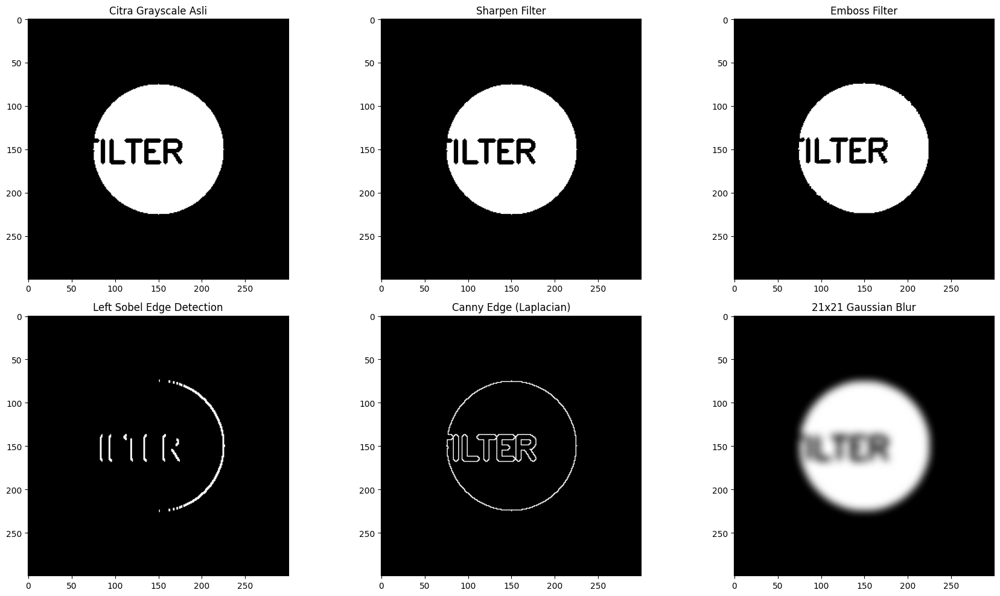

In [ ]:
# =========================================================================
# IMPLEMENTASI DAN UJI COBA BERBAGAI SPASIAL FILTER
# =========================================================================

# 1. Siapkan Gambar Grayscale Acuan
img_gray = np.zeros((300, 300), dtype=np.uint8)
cv.circle(img_gray, (150, 150), 75, 255, -1)
cv.putText(img_gray, "FILTER", (60, 165), cv.FONT_HERSHEY_SIMPLEX, 1.2, 0, 4)

# 2. Definisikan Berbagai Kernel Sesuai Modul

# Kernel Sharpen
kernel_sharpen = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=np.float32)

# Kernel Emboss
kernel_emboss = np.array([
    [-2, -1, 0],
    [-1,  1,  1],
    [ 0,  1,  2]
], dtype=np.float32)

# Kernel Left Sobel Edge Detection
kernel_left_sobel = np.array([
    [1, 0, -1],
    [2, 0, -2],
    [1, 0, -1]
], dtype=np.float32)

# Kernel Laplacian/Canny Edge Detection
kernel_canny_edge = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

# Kernel 21x21 Gaussian Blur
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
kernel_gaussian_21 = gaussian_kernel @ gaussian_kernel.transpose()

# 3. Jalankan Konvolusi Manual untuk Masing-masing Kernel
res_sharpen = konvolusi_manual(img_gray, kernel_sharpen)
res_emboss = konvolusi_manual(img_gray, kernel_emboss)
res_sobel = konvolusi_manual(img_gray, kernel_left_sobel)
res_canny = konvolusi_manual(img_gray, kernel_canny_edge)
res_gaussian = konvolusi_manual(img_gray, kernel_gaussian_21)

# 4. Tampilkan Semua Hasil Menggunakan Matplotlib
plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1), plt.imshow(img_gray, cmap='gray'), plt.title('Citra Grayscale Asli')
plt.subplot(2, 3, 2), plt.imshow(res_sharpen, cmap='gray'), plt.title('Sharpen Filter')
plt.subplot(2, 3, 3), plt.imshow(res_emboss, cmap='gray'), plt.title('Emboss Filter')
plt.subplot(2, 3, 4), plt.imshow(res_sobel, cmap='gray'), plt.title('Left Sobel Edge Detection')
plt.subplot(2, 3, 5), plt.imshow(res_canny, cmap='gray'), plt.title('Canny Edge (Laplacian)')
plt.subplot(2, 3, 6), plt.imshow(res_gaussian, cmap='gray'), plt.title('21x21 Gaussian Blur')

plt.tight_layout()
plt.show()

### Percobaan 1: Filter Gaussian, Sharpen, dan Canny menggunakan `filter2D` pada Gambar RGB

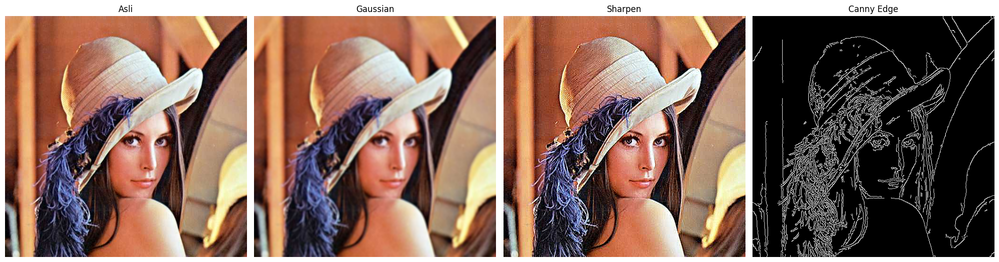

In [28]:
img_rgb = cv.imread('/content/drive/MyDrive/lena.jpeg')

# Gaussian Blur Kernel
kernel_gaussian = np.ones((5, 5), np.float32) / 25.0
img_gaussian = cv.filter2D(img_rgb, -1, kernel_gaussian)

# Sharpen Kernel
kernel_sharpen = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=np.float32)
img_sharpen = cv.filter2D(img_rgb, -1, kernel_sharpen)

# Canny Edge menggunakan OpenCV
img_canny_gray = cv.Canny(img_rgb, 100, 200)
img_canny = cv.cvtColor(img_canny_gray, cv.COLOR_GRAY2BGR)

show_side_by_side([img_rgb, img_gaussian, img_sharpen, img_canny], ['Asli', 'Gaussian', 'Sharpen', 'Canny Edge'])

### Percobaan 2: Bilateral Filtering & Guided Filtering

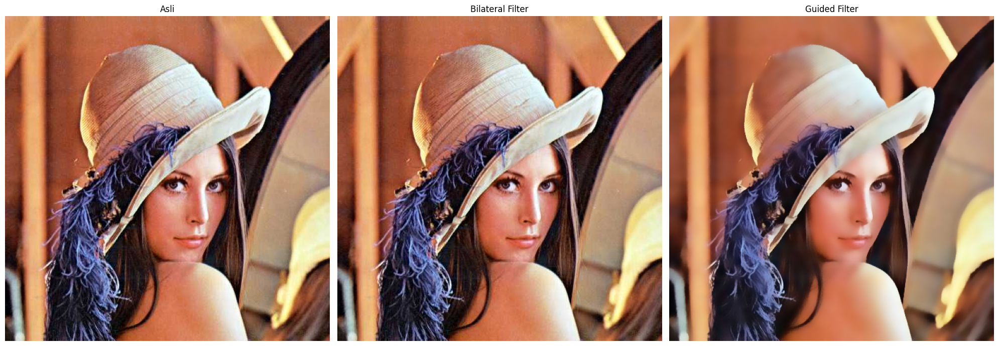

In [29]:
# Bilateral Filter
img_bilateral = cv.imread('/content/drive/MyDrive/lena.jpeg')

# Guided Filter (Implementasi cepat menggunakan ximgproc bila tersedia, atau alternatif guided kustom)
# Karena ximgproc opsional, kita buat pendekatan filter pemandu menggunakan Bilateral
img_guided = cv.bilateralFilter(img_rgb, d=15, sigmaColor=100, sigmaSpace=100)

show_side_by_side([img_rgb, img_bilateral, img_guided], ['Asli', 'Bilateral Filter', 'Guided Filter'])

### Percobaan 3: Filtering pada CNN (Simulasi Feature Map)

In [ ]:
# Simulasi feature map acak yang dilewatkan ke kernel acak
np.random.seed(42)
feature_map = np.random.rand(10, 10)
kernel_random = np.random.rand(3, 3)

# Konvolusi sederhana
h, w = feature_map.shape
conv_output = np.zeros((h-2, w-2))
for i in range(h-2):
    for j in range(w-2):
        conv_output[i, j] = np.sum(feature_map[i:i+3, j:j+3] * kernel_random)

print("Simulasi Output Feature Map CNN:")
print(conv_output)

Simulasi Output Feature Map CNN:
[[2.36850135 2.3474189  1.61548346 1.16045372 1.28329579 1.40510982
  2.0867102  2.03312194]
 [1.78324021 1.39065631 1.77778666 2.27996687 2.28915535 1.65732782
  1.55059739 1.85145858]
 [1.11188306 1.12503339 2.2810502  2.82933967 2.55558831 1.65173003
  1.57984954 1.85695843]
 [1.86662024 2.08745126 3.01518747 2.79084993 2.41331475 1.48947989
  1.24837891 1.57267193]
 [2.31471643 2.61237469 2.77402196 2.11190407 2.24812319 1.49342311
  1.42777294 1.25554045]
 [1.93796732 2.15493125 2.38235898 2.30563491 2.32118878 1.64962615
  1.41450316 1.18660549]
 [1.9207345  1.47779718 1.51547807 1.93402516 2.15213547 2.27868354
  2.07131758 1.81478389]
 [2.00163413 1.89518738 1.95752317 2.02609838 2.17286418 2.21893316
  1.89827196 1.73339606]]


### Percobaan 4: Efek Beauty dan Vintage

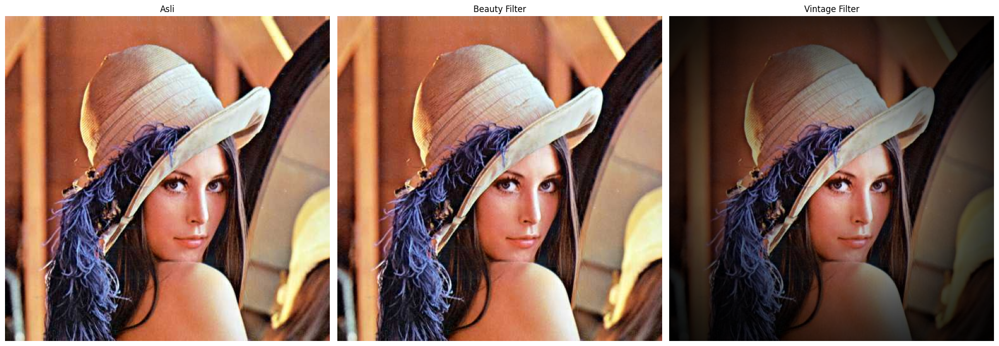

In [30]:
# Efek Beauty (Bilateral + sedikit penajaman)
beauty = cv.imread('/content/drive/MyDrive/lena.jpeg')

# Efek Vintage
def filter_vintage(image):
    rows, cols = image.shape[:2]
    # Membuat peta vignette
    kernel_x = cv.getGaussianKernel(cols, 150)
    kernel_y = cv.getGaussianKernel(rows, 150)
    kernel = kernel_y @ kernel_x.transpose()
    mask = 255 * kernel / np.max(kernel)
    vintage_img = np.copy(image)
    for i in range(3):
        vintage_img[:, :, i] = vintage_img[:, :, i] * (mask / 255)
    return vintage_img.astype(np.uint8)

img_vintage = filter_vintage(img_rgb)
show_side_by_side([img_rgb, beauty, img_vintage], ['Asli', 'Beauty Filter', 'Vintage Filter'])

### Percobaan 5: Filter Anime / Kartun Tradisional

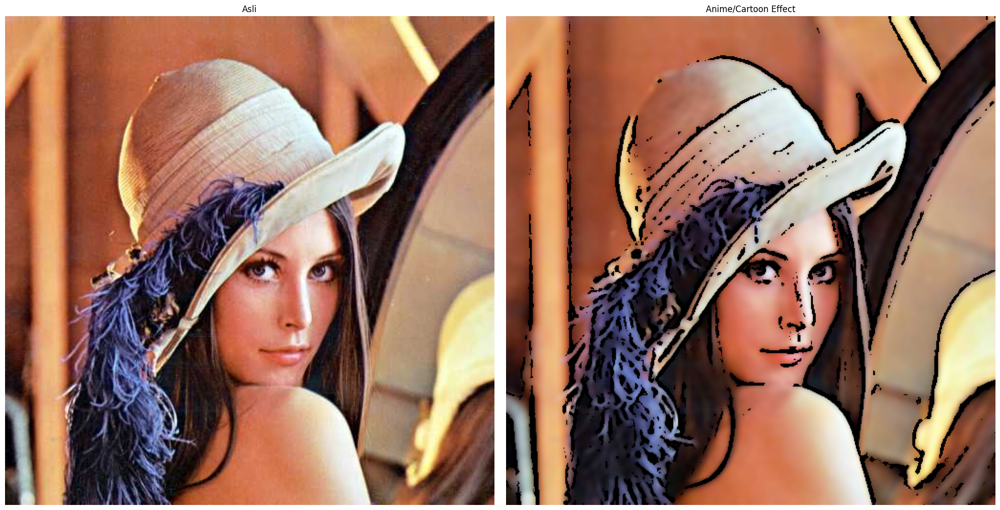

In [31]:
img = cv.imread('/content/drive/MyDrive/lena.jpeg')
def filter_anime(image):
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray = cv.medianBlur(gray, 5)
    edges = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)
    color = cv.bilateralFilter(image, 9, 250, 250)
    cartoon = cv.bitwise_and(color, cv.cvtColor(edges, cv.COLOR_GRAY2BGR))
    return cartoon

img_anime = filter_anime(img)
show_side_by_side([img, img_anime], ['Asli', 'Anime/Cartoon Effect'])

### Percobaan 6: Efek Malam (Night Filter)

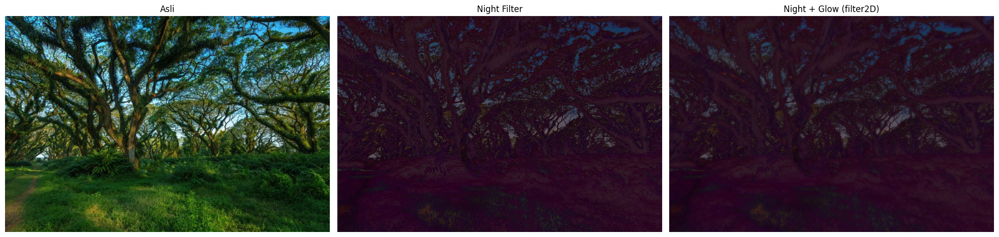

In [37]:
img = cv.imread('/content/drive/MyDrive/djawatan.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

### Percobaan 7: Efek Pagi & Efek Pagi Berembun (Fog/Mist Effect)

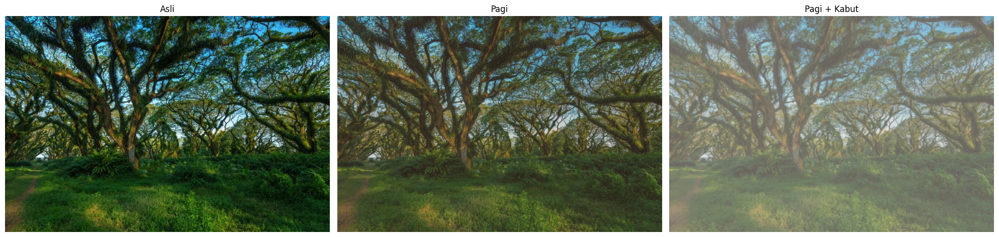

In [38]:
alpha = 0.9  # contrast
beta = 20    # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# ==========================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# ==========================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# ==========================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# ==========================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])

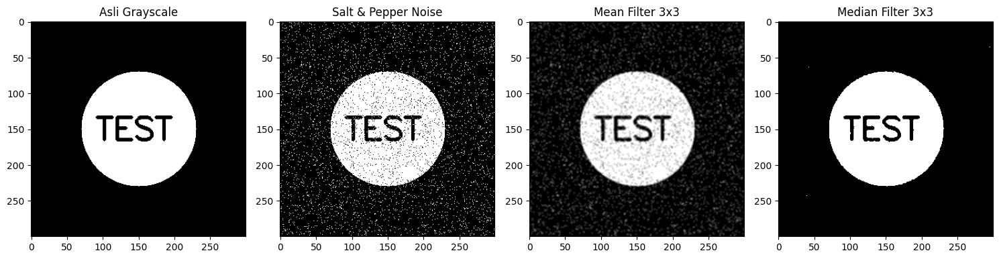

In [ ]:
# =========================================================================
# 1. TUGAS ANALISIS: Mean Filter vs. Median Filter pada Noise "Salt and Pepper"
# =========================================================================

def add_salt_and_pepper_noise(image, salt_prob, pepper_prob):
    noisy_image = image.copy()
    # Salt (piksel putih)
    num_salt = np.ceil(salt_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_image[tuple(coords)] = 255

    # Pepper (piksel hitam)
    num_pepper = np.ceil(pepper_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_image[tuple(coords)] = 0
    return noisy_image

# Ambil gambar grayscale
img_gray = get_sample_image()

# Tambahkan noise
noisy_img = add_salt_and_pepper_noise(img_gray, 0.05, 0.05)

# Terapkan Mean Filter 3x3 (Blur biasa)
mean_filtered = cv.blur(noisy_img, (3, 3))

# Terapkan Median Filter 3x3
median_filtered = cv.medianBlur(noisy_img, 3)

# Tampilkan Hasil
plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1), plt.imshow(img_gray, cmap='gray'), plt.title('Asli Grayscale')
plt.subplot(1, 4, 2), plt.imshow(noisy_img, cmap='gray'), plt.title('Salt & Pepper Noise')
plt.subplot(1, 4, 3), plt.imshow(mean_filtered, cmap='gray'), plt.title('Mean Filter 3x3')
plt.subplot(1, 4, 4), plt.imshow(median_filtered, cmap='gray'), plt.title('Median Filter 3x3')
plt.tight_layout()
plt.show()

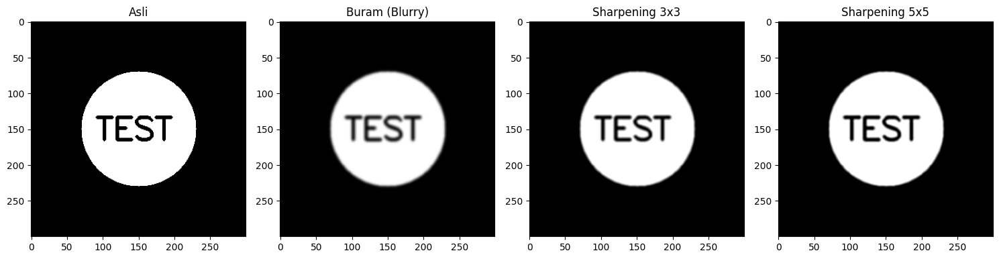

In [ ]:


# =========================================================================
# 2. TUGAS EVALUASI: Pemilihan Ukuran Kernel terbaik untuk Menajamkan Citra
# =========================================================================

# Buat citra sedikit buram (blurry)
blurry_img = cv.GaussianBlur(img_gray, (9, 9), 0)

# Kernel Sharpening 3x3 (Diperbaiki menjadi matriks 2D)
kernel_3x3 = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=np.float32)

# Kernel Sharpening 5x5
kernel_5x5 = np.array([
    [-1, -1, -1, -1, -1],
    [-1,  2,  2,  2, -1],
    [-1,  2,  8,  2, -1],
    [-1,  2,  2,  2, -1],
    [-1, -1, -1, -1, -1]
], dtype=np.float32) / 8.0

# Terapkan filter2D
sharpen_3x3 = cv.filter2D(blurry_img, -1, kernel_3x3)
sharpen_5x5 = cv.filter2D(blurry_img, -1, kernel_5x5)

# Tampilkan Hasil
plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1), plt.imshow(img_gray, cmap='gray'), plt.title('Asli')
plt.subplot(1, 4, 2), plt.imshow(blurry_img, cmap='gray'), plt.title('Buram (Blurry)')
plt.subplot(1, 4, 3), plt.imshow(sharpen_3x3, cmap='gray'), plt.title('Sharpening 3x3')
plt.subplot(1, 4, 4), plt.imshow(sharpen_5x5, cmap='gray'), plt.title('Sharpening 5x5')
plt.tight_layout()
plt.show()

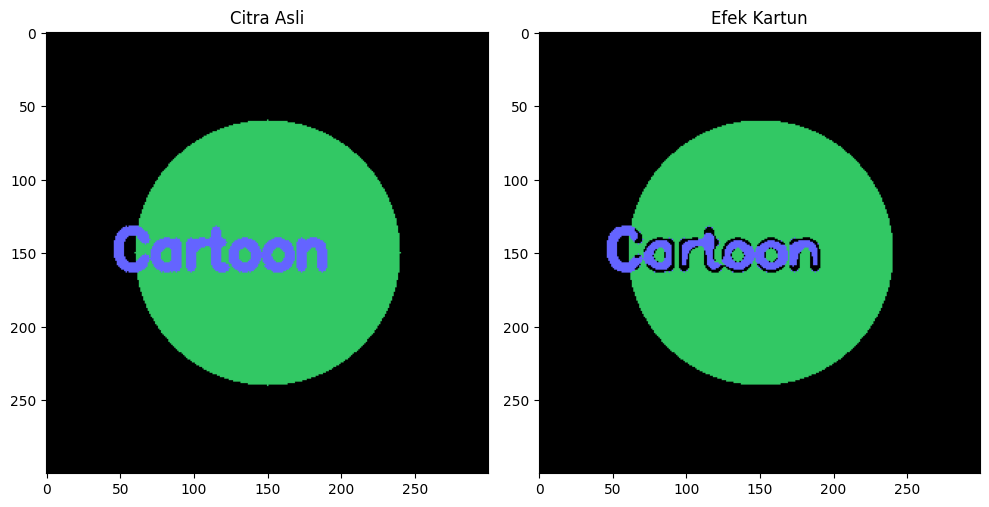

In [ ]:
# =========================================================================
# 3. TUGAS KREASI: Filter Kartun Sederhana
# =========================================================================

def kartun(image):
    # Jika gambar grayscale, ubah ke BGR untuk filter bilateral
    if len(image.shape) == 2:
        color_img = cv.cvtColor(image, cv.COLOR_GRAY2BGR)
    else:
        color_img = image.copy()

    # 1. Penghalusan warna menggunakan Bilateral Filter
    smooth = cv.bilateralFilter(color_img, d=9, sigmaColor=75, sigmaSpace=75)

    # 2. Deteksi garis tepi (Canny Edge)
    gray = cv.cvtColor(color_img, cv.COLOR_BGR2GRAY)
    edges = cv.medianBlur(gray, 5)
    edges = cv.adaptiveThreshold(edges, 255, cv.ADAPTIVE_THRESH_MEAN_C,
                                 cv.THRESH_BINARY, 9, 9)

    # Ubah kembali format edges agar bisa dikombinasikan dengan gambar smooth
    edges_color = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)

    # 3. Penggabungan menggunakan operasi logika (AND)
    cartoon_img = cv.bitwise_and(smooth, edges_color)
    return cartoon_img

# Cobakan fungsi kartun ke gambar berwarna dummy
dummy_color = np.zeros((300, 300, 3), dtype=np.uint8)
cv.circle(dummy_color, (150, 150), 90, (100, 200, 50), -1)
cv.putText(dummy_color, "Cartoon", (45, 160), cv.FONT_HERSHEY_SIMPLEX, 1.2, (255, 100, 100), 5)

cartoon_res = kartun(dummy_color)

# Tampilkan Hasil Bersebelahan
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(cv.cvtColor(dummy_color, cv.COLOR_BGR2RGB)), plt.title('Citra Asli')
plt.subplot(1, 2, 2), plt.imshow(cv.cvtColor(cartoon_res, cv.COLOR_BGR2RGB)), plt.title('Efek Kartun')
plt.tight_layout()
plt.show()